In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [10]:
df = pd.read_csv("bank.csv.csv", sep=';')
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [11]:

df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [12]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].replace("unknown", df[col].mode()[0])


In [13]:
df = pd.get_dummies(df, drop_first=True)


In [14]:
X = df.drop("y_yes", axis=1)
y = df["y_yes"]


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [16]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5)

In [17]:
y_pred = model.predict(X_test)


In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8977109366360722


In [19]:
print(confusion_matrix(y_test, y_pred))


[[7754  198]
 [ 727  364]]


In [20]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.91      0.98      0.94      7952
        True       0.65      0.33      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



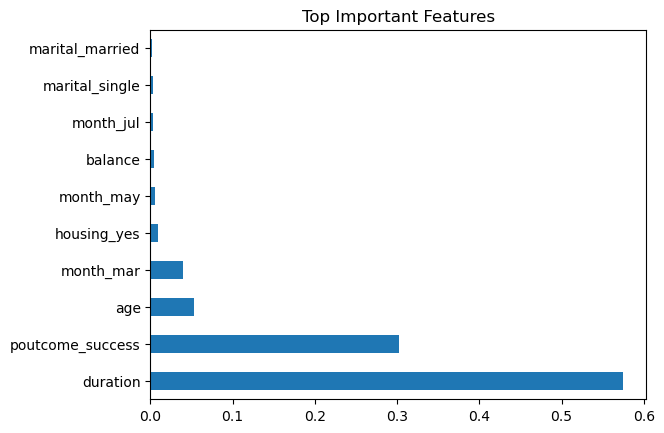

In [21]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()
